# 💸 SpendBehavior Analyzer — Data Wrangling & EDA
**Coding Camp 2026 — DBS Foundation | Tim CC26-PSU268**

---
## 📋 Deskripsi Proyek
SpendBehavior Analyzer adalah platform berbasis web yang membantu pengguna memahami pola pengeluaran mereka dari sisi perilaku, bukan sekadar nominal. Notebook ini mencakup:
1. Gathering Data
2. Assessing Data
3. Cleaning Data
4. Business Questions
5. Exploratory Data Analysis (EDA)
6. Persiapan Data untuk Model
7. Data Dictionary

**Dataset:** Financial Transactions Dataset (Expenses & Income)  
**Sumber:** https://www.kaggle.com/datasets/artemkabseu/financial-transactions-dataset-expenses-and-income

> ⚠️ **Catatan:** Jalankan cell pertama untuk download dataset dari Kaggle, atau letakkan file CSV secara manual di folder yang sama.

---
## 0. Setup & Import Library

In [30]:
# ============================================================
# CELL 0 — Setup & Import
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# ---- Style ----
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#EC4899']
PRIMARY  = '#2563EB'

print('✅ Library berhasil diimpor.')

✅ Library berhasil diimpor.


---
## 1. Gathering Data
### 1.1 Download Dataset (via KaggleHub)
> Menggunakan `kagglehub` untuk download 2 dataset:
> 1. **Fraud Detection** — untuk deteksi anomali transaksi
> 2. **Financial Transactions** — untuk analisis perilaku belanja

In [31]:
# ============================================================
# CELL 1 — Gathering Data via KaggleHub
# ============================================================
import kagglehub

# ---- Download Dataset 1: Fraud Detection ----
print('📥 Downloading Fraud Detection dataset...')
path_fraud = kagglehub.dataset_download("kartik2112/fraud-detection")
print(f"✅ Path: {path_fraud}")

# ---- Download Dataset 2: Financial Transactions ----
print('\n📥 Downloading Financial Transactions dataset...')
path_transactions = kagglehub.dataset_download("artemkabseu/financial-transactions-dataset-expenses-and-income")
print(f"✅ Path: {path_transactions}")

# ---- Load Financial Transactions Dataset ----
# Cari file CSV dalam folder
import glob
csv_files = glob.glob(f"{path_transactions}/*.csv")
print(f'\n📂 CSV files found: {csv_files}')

# Asumsi file pertama adalah dataset utama
if len(csv_files) > 0:
    df_raw = pd.read_csv(csv_files[0])
    print(f'\n✅ Data berhasil dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
    print(f'📝 Kolom: {df_raw.columns.tolist()}')
    print('\n5 baris pertama:')
    df_raw.head()
else:
    print('⚠️  Tidak ada CSV file ditemukan. Menggunakan simulasi data...')
    
    # ---- SIMULASI DATA (fallback) ----
    np.random.seed(42)
    n = 2500

    categories = [
        'Food & Dining', 'Transportation', 'Shopping', 'Entertainment',
        'Health & Medical', 'Utilities & Bills', 'Groceries',
        'Education', 'Personal Care', 'Travel'
    ]
    cat_weights = [0.25, 0.15, 0.18, 0.10, 0.07, 0.08, 0.07, 0.04, 0.04, 0.02]

    sub_categories = {
        'Food & Dining'     : ['Cafe', 'Restaurant', 'Fast Food', 'Online Food Order'],
        'Transportation'    : ['Ojek Online', 'Taxi', 'Bensin', 'Bus/KRL'],
        'Shopping'          : ['Fashion', 'Elektronik', 'Online Shop', 'Aksesoris'],
        'Entertainment'     : ['Streaming', 'Bioskop', 'Game', 'Konser'],
        'Health & Medical'  : ['Obat', 'Dokter', 'Gym', 'Vitamin'],
        'Utilities & Bills' : ['Listrik', 'Internet', 'Air', 'Pulsa/Data'],
        'Groceries'         : ['Supermarket', 'Pasar', 'Mini Market'],
        'Education'         : ['Kursus', 'Buku', 'Seminar'],
        'Personal Care'     : ['Salon', 'Skincare', 'Barbershop'],
        'Travel'            : ['Hotel', 'Tiket', 'Oleh-oleh']
    }

    payment_methods = ['QRIS', 'E-Wallet', 'Debit Card', 'Cash', 'Credit Card']
    payment_weights = [0.35, 0.25, 0.20, 0.12, 0.08]

    date_range = pd.date_range('2023-01-01', '2023-12-31', freq='D')

    cat_col  = np.random.choice(categories, size=n, p=cat_weights)
    sub_col  = [np.random.choice(sub_categories[c]) for c in cat_col]
    date_col = np.random.choice(date_range, size=n)
    pay_col  = np.random.choice(payment_methods, size=n, p=payment_weights)

    # Amount berdasarkan kategori (lebih realistis)
    amount_map = {
        'Food & Dining'     : (15_000, 120_000),
        'Transportation'    : (10_000,  80_000),
        'Shopping'          : (50_000, 500_000),
        'Entertainment'     : (15_000, 200_000),
        'Health & Medical'  : (20_000, 350_000),
        'Utilities & Bills' : (50_000, 400_000),
        'Groceries'         : (30_000, 300_000),
        'Education'         : (50_000, 500_000),
        'Personal Care'     : (20_000, 200_000),
        'Travel'            : (100_000, 2_000_000)
    }

    amount_col = np.array([
        np.random.randint(amount_map[c][0], amount_map[c][1])
        for c in cat_col
    ])

    user_ids = np.random.choice([f'USR{str(i).zfill(3)}' for i in range(1, 51)], size=n)

    df_raw = pd.DataFrame({
        'transaction_id' : [f'TXN{str(i).zfill(5)}' for i in range(n)],
        'user_id'        : user_ids,
        'date'           : pd.to_datetime(date_col),
        'category'       : cat_col,
        'sub_category'   : sub_col,
        'amount'         : amount_col,
        'payment_method' : pay_col,
        'type'           : 'expense'
    })

    # Sisipkan beberapa missing value untuk simulasi data kotor
    miss_idx = np.random.choice(df_raw.index, size=50, replace=False)
    df_raw.loc[miss_idx[:20], 'sub_category'] = np.nan
    df_raw.loc[miss_idx[20:35], 'payment_method'] = np.nan
    df_raw.loc[miss_idx[35:], 'amount'] = np.nan

    # Sisipkan duplikat
    dup_idx = np.random.choice(df_raw.index, size=30, replace=False)
    df_raw = pd.concat([df_raw, df_raw.loc[dup_idx]], ignore_index=True)

    print(f'✅ Data berhasil dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
    print('\n📋 5 baris pertama:')
    df_raw.head()

📥 Downloading Fraud Detection dataset...
✅ Path: C:\Users\hadis\.cache\kagglehub\datasets\kartik2112\fraud-detection\versions\1

📥 Downloading Financial Transactions dataset...
✅ Path: C:\Users\hadis\.cache\kagglehub\datasets\artemkabseu\financial-transactions-dataset-expenses-and-income\versions\4

📂 CSV files found: ['C:\\Users\\hadis\\.cache\\kagglehub\\datasets\\artemkabseu\\financial-transactions-dataset-expenses-and-income\\versions\\4\\Expenses_clean.csv', 'C:\\Users\\hadis\\.cache\\kagglehub\\datasets\\artemkabseu\\financial-transactions-dataset-expenses-and-income\\versions\\4\\Income_clean.csv']

✅ Data berhasil dimuat: 938 baris × 6 kolom
📝 Kolom: ['date_time', 'category', 'account', 'amount', 'currency', 'tags']

5 baris pertama:


In [32]:
# ---- Load Fraud Detection Dataset (Bonus) ----
print('\n' + '='*60)
print('📊 BONUS: FRAUD DETECTION DATASET')
print('='*60)
fraud_csv_files = glob.glob(f"{path_fraud}/*.csv")
if len(fraud_csv_files) > 0:
    df_fraud = pd.read_csv(fraud_csv_files[0])
    print(f'✅ Fraud dataset berhasil dimuat: {df_fraud.shape[0]:,} baris × {df_fraud.shape[1]} kolom')
    print(f'📝 Kolom: {df_fraud.columns.tolist()}')
    print('\n5 baris pertama:')
    print(df_fraud.head())
    print('\nStatistik fraud rate:')
    if 'isFraud' in df_fraud.columns or 'Class' in df_fraud.columns:
        fraud_col = 'isFraud' if 'isFraud' in df_fraud.columns else 'Class'
        print(df_fraud[fraud_col].value_counts())
else:
    print('⚠️  Fraud dataset tidak ditemukan.')


📊 BONUS: FRAUD DETECTION DATASET
✅ Fraud dataset berhasil dimuat: 555,719 baris × 23 kolom
📝 Kolom: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

5 baris pertama:
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashl

### 1.2 Fraud Detection Dataset (Bonus Feature)
Dataset ini dapat digunakan untuk mendeteksi transaksi mencurigakan atau anomali. Nantinya dapat diintegrasikan dengan SpendBehavior Analyzer untuk Smart Warning System.

---
## 1.3 Column Mapping & Standardisasi
> Sesuaikan nama kolom dari dataset real dengan schema yang digunakan

In [33]:
# ============================================================
# CELL 1.3 — Column Mapping & Standardisasi
# ============================================================
print('=' * 60)
print('📋 ORIGINAL COLUMNS:', df_raw.columns.tolist())
print('=' * 60)

# Mapping kolom dari dataset real ke schema standar
# Jika dataset tidak memiliki kolom tertentu, buat dengan default value
column_mapping = {
    'transaction_date': 'date',
    'Date': 'date',
    'date_time': 'date',
    'TransactionDate': 'date',
    'Amount': 'amount',
    'TransAmount': 'amount',
    'Category': 'category',
    'SubCategory': 'sub_category',
    'PaymentMethod': 'payment_method',
    'UserID': 'user_id',
    'User_ID': 'user_id',
    'TransactionType': 'type',
    'Type': 'type',
}

# Lakukan rename kolom
for old_col, new_col in column_mapping.items():
    if old_col in df_raw.columns and new_col not in df_raw.columns:
        df_raw.rename(columns={old_col: new_col}, inplace=True)
        print(f'✅ Renamed: {old_col} → {new_col}')

# Kolom wajib untuk analisis
required_columns = ['date', 'amount', 'category']
missing_cols = [col for col in required_columns if col not in df_raw.columns]

if missing_cols:
    print(f'\n⚠️  Missing required columns: {missing_cols}')
    print('ℹ️  Adding default columns and proceeding with dataset as-is...')
else:
    print(f'\n✅ Semua kolom wajib tersedia: {required_columns}')

# Tambah kolom default jika tidak ada
if 'date' not in df_raw.columns:
    df_raw['date'] = pd.Timestamp.now()
    print('ℹ️  Added default date column')
    
if 'sub_category' not in df_raw.columns:
    df_raw['sub_category'] = df_raw['category'] if 'category' in df_raw.columns else 'Other'
    print('ℹ️  Added sub_category column')
    
if 'payment_method' not in df_raw.columns:
    df_raw['payment_method'] = 'Unknown'
    print('ℹ️  Added payment_method column')
    
if 'user_id' not in df_raw.columns:
    df_raw['user_id'] = 'USER_' + df_raw.index.astype(str)
    print('ℹ️  Added user_id column')
    
if 'type' not in df_raw.columns:
    df_raw['type'] = 'expense'
    print('ℹ️  Added type column')

print(f'\n✅ Final columns: {df_raw.columns.tolist()}')
print(f'📊 Shape: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')

📋 ORIGINAL COLUMNS: ['date_time', 'category', 'account', 'amount', 'currency', 'tags']
✅ Renamed: date_time → date

✅ Semua kolom wajib tersedia: ['date', 'amount', 'category']
ℹ️  Added sub_category column
ℹ️  Added payment_method column
ℹ️  Added user_id column
ℹ️  Added type column

✅ Final columns: ['date', 'category', 'account', 'amount', 'currency', 'tags', 'sub_category', 'payment_method', 'user_id', 'type']
📊 Shape: 938 baris × 10 kolom


---
## 2. Assessing Data
### 2.1 Gambaran Umum Dataset

In [34]:
# ============================================================
# CELL 2 — Assessing Data
# ============================================================
print('=' * 55)
print('📊 GAMBARAN UMUM DATASET')
print('=' * 55)
print(f'Jumlah baris   : {df_raw.shape[0]:,}')
print(f'Jumlah kolom   : {df_raw.shape[1]}')
print()
df_raw.info()

📊 GAMBARAN UMUM DATASET
Jumlah baris   : 938
Jumlah kolom   : 10

<class 'pandas.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            938 non-null    str    
 1   category        938 non-null    str    
 2   account         938 non-null    str    
 3   amount          938 non-null    float64
 4   currency        938 non-null    str    
 5   tags            938 non-null    str    
 6   sub_category    938 non-null    str    
 7   payment_method  938 non-null    str    
 8   user_id         938 non-null    str    
 9   type            938 non-null    str    
dtypes: float64(1), str(9)
memory usage: 141.7 KB


In [35]:
# 2.2 Statistik Deskriptif
print('=' * 55)
print('📈 STATISTIK DESKRIPTIF (NUMERIK)')
print('=' * 55)
df_raw.describe()

📈 STATISTIK DESKRIPTIF (NUMERIK)


,amount
count,938.000000
mean,15.842217
std,78.291145
min,0.000000
25%,1.000000
50%,2.000000
75%,10.000000
max,1172.000000


❓ MISSING VALUES
         Kolom  Jumlah Missing  Persentase (%)
          date               0             0.0
      category               0             0.0
       account               0             0.0
        amount               0             0.0
      currency               0             0.0
          tags               0             0.0
  sub_category               0             0.0
payment_method               0             0.0
       user_id               0             0.0
          type               0             0.0


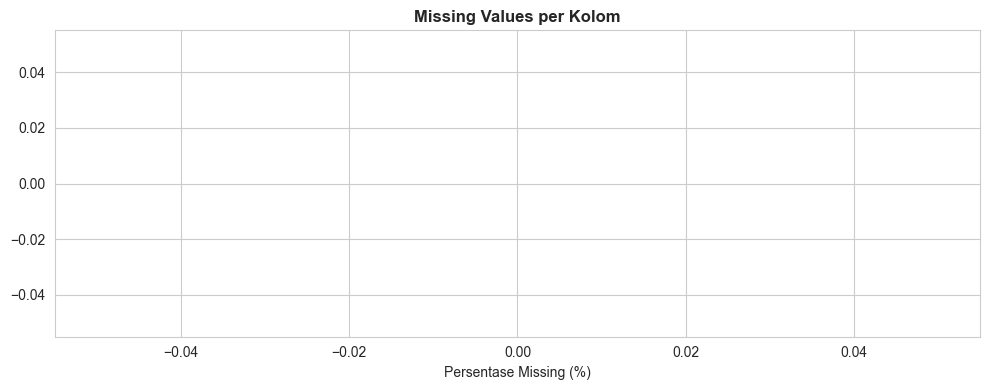

In [36]:
# 2.3 Cek Missing Values
print('=' * 55)
print('❓ MISSING VALUES')
print('=' * 55)
missing = df_raw.isnull().sum().reset_index()
missing.columns = ['Kolom', 'Jumlah Missing']
missing['Persentase (%)'] = (missing['Jumlah Missing'] / len(df_raw) * 100).round(2)
print(missing.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 4))
missing_viz = missing[missing['Jumlah Missing'] > 0]
ax.barh(missing_viz['Kolom'], missing_viz['Persentase (%)'], color='#EF4444')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Missing Values per Kolom', fontweight='bold')
for i, v in enumerate(missing_viz['Persentase (%)']):
    ax.text(v + 0.1, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

In [37]:
# 2.4 Cek Duplikat
print('=' * 55)
print('🔁 DUPLIKAT')
print('=' * 55)
dup_count = df_raw.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count:,}')
print(f'Persentase           : {dup_count/len(df_raw)*100:.2f}%')

🔁 DUPLIKAT
Jumlah baris duplikat: 0
Persentase           : 0.00%


In [38]:
# 2.5 Cek Nilai Tidak Wajar
print('=' * 55)
print('⚠️  NILAI TIDAK WAJAR')
print('=' * 55)
print(f'Amount ≤ 0   : {(df_raw["amount"] <= 0).sum()} baris')
print(f'Amount > 5jt : {(df_raw["amount"] > 5_000_000).sum()} baris (potensi outlier)')
print()
print('Distribusi tipe transaksi:')
if 'type' in df_raw.columns:
    print(df_raw['type'].value_counts())
else:
    print('Kolom "type" tidak tersedia di df_raw.')
    print('Kolom yang tersedia:', df_raw.columns.tolist())

⚠️  NILAI TIDAK WAJAR
Amount ≤ 0   : 14 baris
Amount > 5jt : 0 baris (potensi outlier)

Distribusi tipe transaksi:
type
expense    938
Name: count, dtype: int64


---
## 3. Cleaning Data

In [39]:
# ============================================================
# CELL 3 — Cleaning Data
# ============================================================
df = df_raw.copy()

# 3.1 Hapus duplikat
before = len(df)
df = df.drop_duplicates()
print(f'[1] Duplikat dihapus  : {before - len(df)} baris → sisa {len(df):,} baris')

# 3.2 Isi missing value
if 'sub_category' in df.columns:
    df['sub_category'] = df['sub_category'].fillna('Lainnya')
else:
    df['sub_category'] = df.get('category', 'Other')

if 'payment_method' not in df.columns:
    df['payment_method'] = 'Unknown'
else:
    df['payment_method'] = df['payment_method'].fillna('Unknown')

df = df.dropna(subset=['amount'])
print(f'[2] Missing value ditangani → sisa {len(df):,} baris')

# 3.3 Hapus amount ≤ 0
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df = df[df['amount'] > 0]
print(f'[3] Amount ≤ 0 dihapus → sisa {len(df):,} baris')

# 3.4 Feature engineering dasar (waktu)
# Parse date column dengan error handling
if 'date' in df.columns:
    try:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date'])
    except Exception as e:
        print(f'⚠️  Error parsing date: {e}')
        df['date'] = pd.Timestamp.now()
else:
    print('⚠️  Column "date" not found. Using current date.')
    df['date'] = pd.Timestamp.now()

df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['month_name']  = df['date'].dt.strftime('%b')
df['day_of_week'] = df['date'].dt.dayofweek         # 0=Mon, 6=Sun
df['day_name']    = df['date'].dt.strftime('%a')
df['hour']        = np.random.choice(range(6, 24), size=len(df))  # simulasi jam
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['is_night']    = (df['hour'] >= 20).astype(int)  # 20:00–23:59
df['week']        = df['date'].dt.isocalendar().week.astype(int)
df['quarter']     = df['date'].dt.quarter

print('[4] Fitur waktu ditambahkan')
print(f'\n✅ Data bersih: {df.shape[0]:,} baris × {df.shape[1]} kolom')
df.head(3)

[1] Duplikat dihapus  : 0 baris → sisa 938 baris
[2] Missing value ditangani → sisa 938 baris
[3] Amount ≤ 0 dihapus → sisa 924 baris
[4] Fitur waktu ditambahkan

✅ Data bersih: 924 baris × 20 kolom


,date,category,account,amount,currency,tags,sub_category,payment_method,user_id,type,year,month,month_name,day_of_week,day_name,hour,is_weekend,is_night,week,quarter
0,2025-11-30,Health,acct_1,114.0,BYN,tag_1,Health,Unknown,USER_0,expense,2025,11,Nov,6,Sun,21,1,1,48,4
1,2025-11-29,Food,acct_1,5.0,BYN,tag_1,Food,Unknown,USER_1,expense,2025,11,Nov,5,Sat,9,1,0,48,4
2,2025-11-27,Public transport,acct_2,1.0,BYN,tag_1,Public transport,Unknown,USER_2,expense,2025,11,Nov,3,Thu,18,0,0,48,4


In [40]:
# 3.5 Konfirmasi tidak ada missing value setelah cleaning
print('Missing value setelah cleaning:')
print(df.isnull().sum())
print(f'\nTotal duplikat: {df.duplicated().sum()}')

Missing value setelah cleaning:
date              0
category          0
account           0
amount            0
currency          0
tags              0
sub_category      0
payment_method    0
user_id           0
type              0
year              0
month             0
month_name        0
day_of_week       0
day_name          0
hour              0
is_weekend        0
is_night          0
week              0
quarter           0
dtype: int64

Total duplikat: 0


---
## 4. Pertanyaan Bisnis
Berikut adalah 5 pertanyaan bisnis yang akan dijawab melalui EDA:

| # | Pertanyaan Bisnis | Fitur SpendBehavior |
|---|---|---|
| **Q1** | Kategori apa yang paling banyak menguras pengeluaran? | Money Leak Detection |
| **Q2** | Kapan (hari/jam) pola pengeluaran impulsif paling sering terjadi? | Behavior Pattern Detection |
| **Q3** | Bagaimana distribusi pengeluaran per bulan? Apakah ada anomali? | Weekly Reflection |
| **Q4** | Pengeluaran kecil-kecilan di sub-kategori mana yang paling sering bocor? | Money Leak Detection |
| **Q5** | Metode pembayaran apa yang paling sering digunakan, dan apakah ada korelasi dengan jumlah pengeluaran? | Behavior Pattern Detection |

---
## 5. Exploratory Data Analysis (EDA)

In [41]:
# ============================================================
# Q1 — Kategori dengan Total Pengeluaran Tertinggi
# ============================================================
cat_sum = df.groupby('category')['amount'].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = [PRIMARY if c == cat_sum.idxmax() else '#93C5FD' for c in cat_sum.index]
axes[0].barh(cat_sum.index, cat_sum.values / 1e6, color=colors)
axes[0].set_xlabel('Total Pengeluaran (juta Rp)')
axes[0].set_title('Q1: Total Pengeluaran per Kategori', fontweight='bold')
for i, v in enumerate(cat_sum.values / 1e6):
    axes[0].text(v + 0.5, i, f'Rp{v:.1f}jt', va='center', fontsize=9)

# Pie chart
axes[1].pie(cat_sum.values, labels=cat_sum.index, autopct='%1.1f%%',
            colors=sns.color_palette('Blues_r', len(cat_sum)),
            startangle=90, pctdistance=0.8)
axes[1].set_title('Proporsi Pengeluaran per Kategori', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'🔴 Kategori tertinggi: {cat_sum.idxmax()} (Rp {cat_sum.max()/1e6:.1f} juta)')

🔴 Kategori tertinggi: Loan given (Rp 0.0 juta)


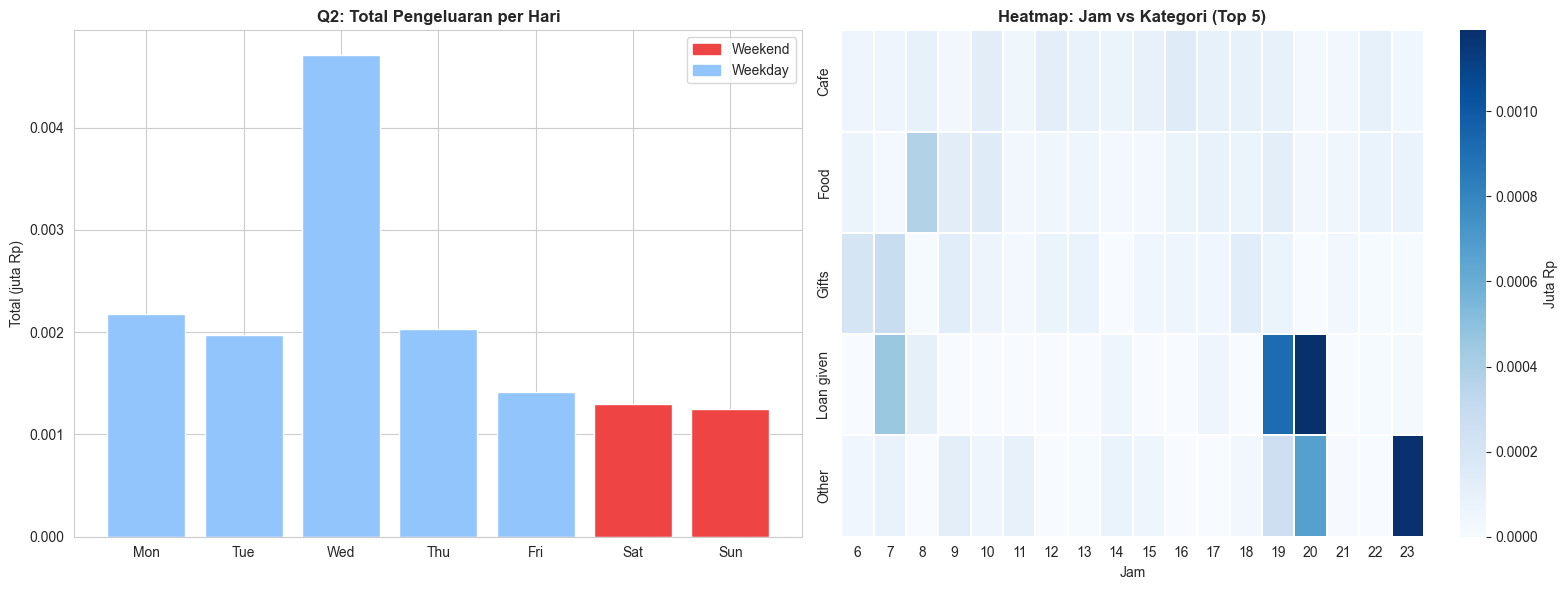

📌 Weekend spending: Rp 0.0jt vs Weekday: Rp 0.0jt


In [42]:
# ============================================================
# Q2 — Pola Waktu: Hari dan Jam Pengeluaran
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Per hari dalam seminggu
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_sum = df.groupby('day_name')['amount'].sum()

# Reindex dengan fill_value 0 jika ada missing days
day_sum = day_sum.reindex(day_order, fill_value=0)

bar_colors = ['#EF4444' if d in ['Sat', 'Sun'] else '#93C5FD' for d in day_order]
axes[0].bar(day_sum.index, day_sum.values / 1e6, color=bar_colors)
axes[0].set_title('Q2: Total Pengeluaran per Hari', fontweight='bold')
axes[0].set_ylabel('Total (juta Rp)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#EF4444', label='Weekend'),
    plt.Rectangle((0,0),1,1, color='#93C5FD', label='Weekday')
])

# Per jam (heatmap format: hour vs kategori top 5)
if 'category' in df.columns:
    top5_cat = df.groupby('category')['amount'].sum().nlargest(5).index.tolist()
    df_top = df[df['category'].isin(top5_cat)]
    hour_cat = df_top.groupby(['hour', 'category'])['amount'].sum().unstack(fill_value=0)
    sns.heatmap(hour_cat.T / 1e6, cmap='Blues', ax=axes[1],
                linewidths=0.3, fmt='.0f', cbar_kws={'label': 'Juta Rp'})
    axes[1].set_title('Heatmap: Jam vs Kategori (Top 5)', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Kolom category tidak ditemukan', ha='center', va='center')
    axes[1].set_title('Heatmap: Jam vs Kategori (N/A)', fontweight='bold')
    
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

weekend_sum = day_sum[['Sat','Sun']].sum() if all(d in day_sum.index for d in ['Sat','Sun']) else 0
weekday_sum = day_sum[['Mon','Tue','Wed','Thu','Fri']].sum() if all(d in day_sum.index for d in ['Mon','Tue','Wed','Thu','Fri']) else 0
print(f'📌 Weekend spending: Rp {weekend_sum/1e6:.1f}jt vs Weekday: Rp {weekday_sum/1e6:.1f}jt')

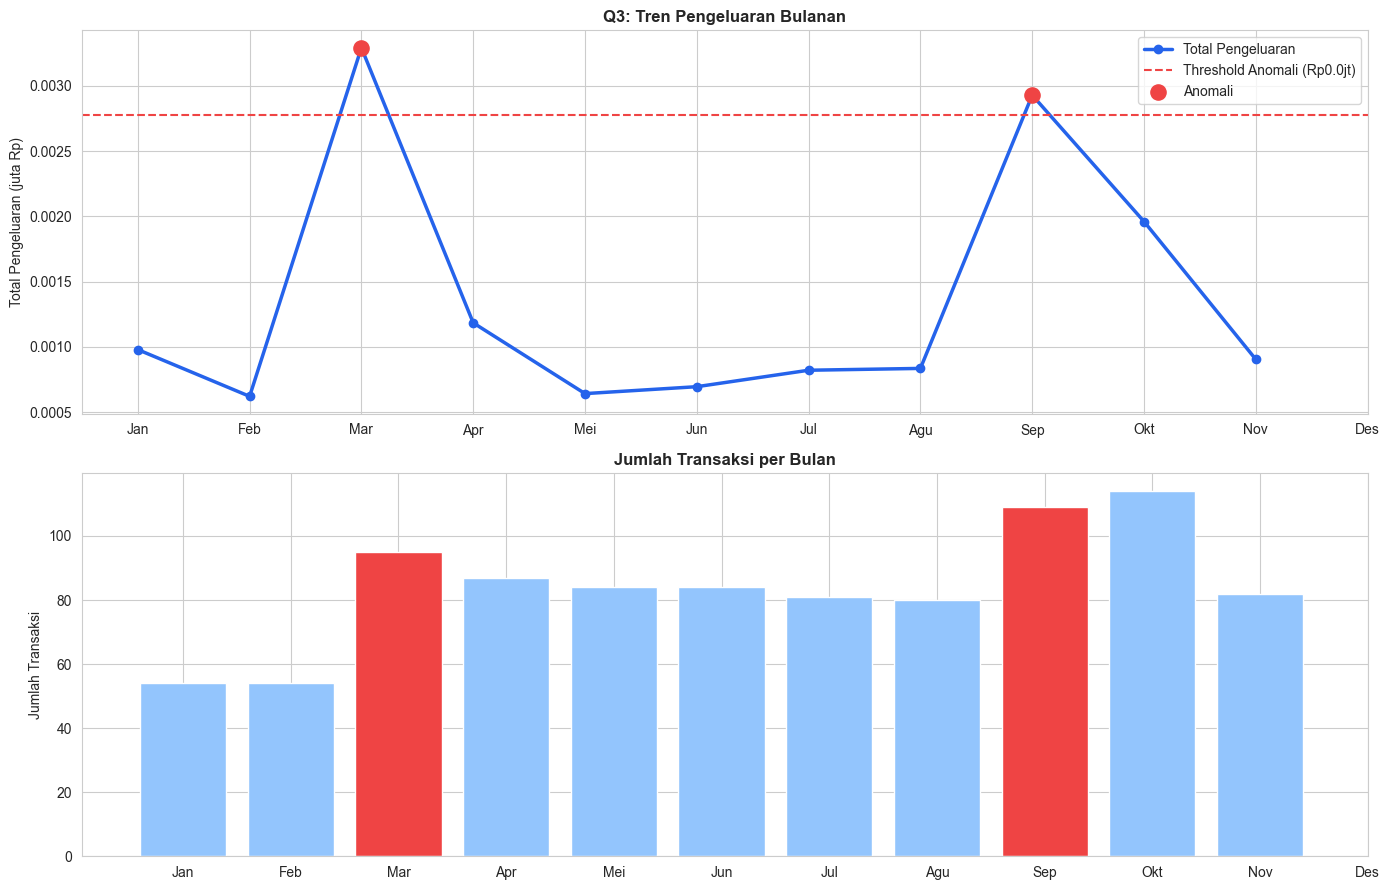

⚠️  Bulan anomali terdeteksi: [3, 9]


In [43]:
# ============================================================
# Q3 — Tren Bulanan dan Deteksi Anomali
# ============================================================
monthly = df.groupby('month').agg(
    total=('amount', 'sum'),
    count=('amount', 'count'),
    avg=('amount', 'mean')
).reset_index()

# Deteksi anomali: bulan yang total-nya > mean + 1.5*std
threshold = monthly['total'].mean() + 1.5 * monthly['total'].std()
monthly['anomaly'] = monthly['total'] > threshold

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Line chart total
axes[0].plot(monthly['month'], monthly['total']/1e6, marker='o',
             color=PRIMARY, linewidth=2.5, label='Total Pengeluaran')
axes[0].axhline(threshold/1e6, color='#EF4444', linestyle='--',
                linewidth=1.5, label=f'Threshold Anomali (Rp{threshold/1e6:.1f}jt)')
anomaly_months = monthly[monthly['anomaly']]
axes[0].scatter(anomaly_months['month'], anomaly_months['total']/1e6,
                color='#EF4444', s=120, zorder=5, label='Anomali')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
axes[0].set_ylabel('Total Pengeluaran (juta Rp)')
axes[0].set_title('Q3: Tren Pengeluaran Bulanan', fontweight='bold')
axes[0].legend()

# Jumlah transaksi per bulan
axes[1].bar(monthly['month'], monthly['count'],
            color=['#EF4444' if a else '#93C5FD' for a in monthly['anomaly']])
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_title('Jumlah Transaksi per Bulan', fontweight='bold')

plt.tight_layout()
plt.show()

if len(anomaly_months) > 0:
    print(f'⚠️  Bulan anomali terdeteksi: {anomaly_months["month"].tolist()}')
else:
    print('✅ Tidak ada anomali signifikan ditemukan.')

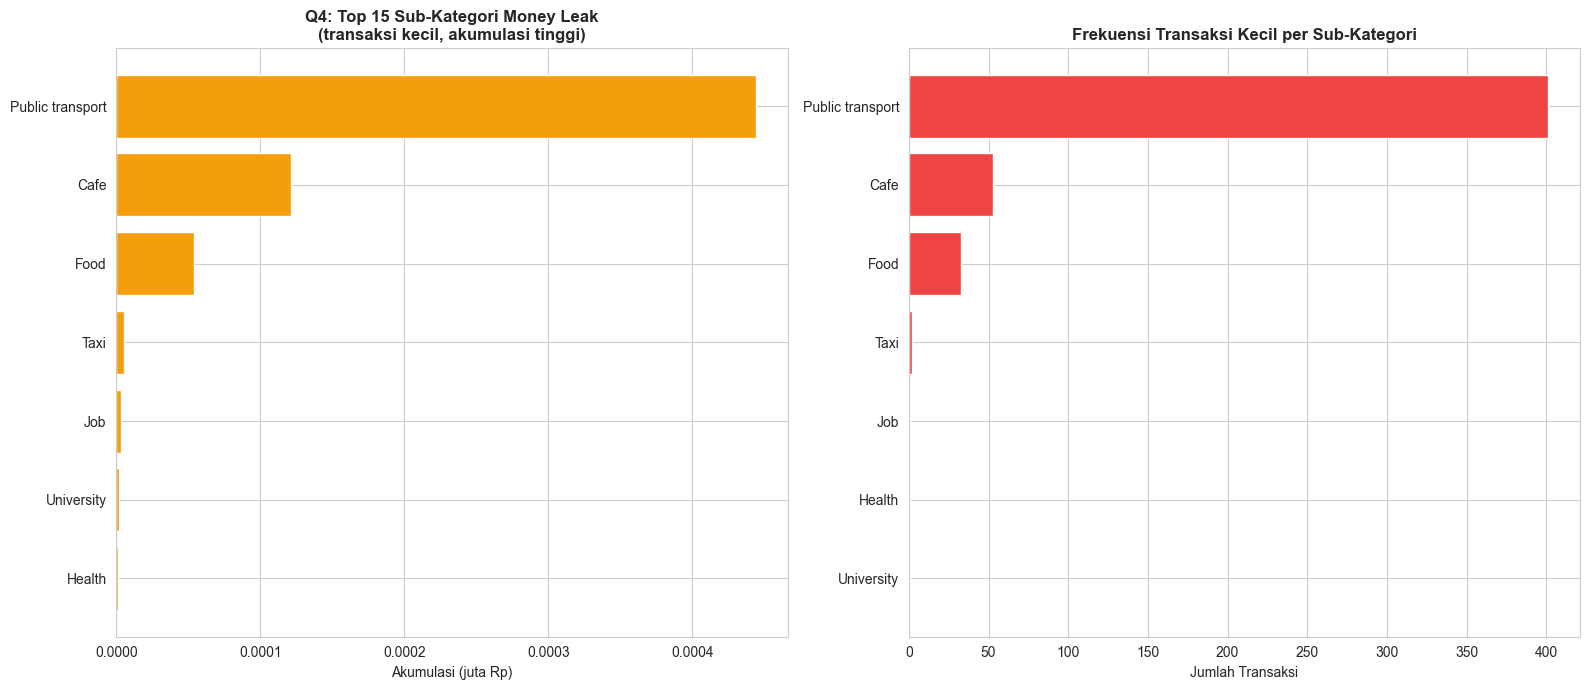

💧 Median amount: Rp 3
💧 Total bocor dari transaksi kecil: Rp 0.0 juta


In [44]:
# ============================================================
# Q4 — Money Leak Detection: Sub-Kategori Pengeluaran Kecil
# ============================================================
# Pengeluaran kecil = amount di bawah median
median_amount = df['amount'].median()
df_small = df[df['amount'] <= median_amount]

leak = df_small.groupby('sub_category').agg(
    total=('amount','sum'),
    freq=('amount','count'),
    avg=('amount','mean')
).sort_values('total', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Total
leak_plot = leak.sort_values('total')
axes[0].barh(leak_plot.index, leak_plot['total']/1e6, color='#F59E0B')
axes[0].set_title('Q4: Top 15 Sub-Kategori Money Leak\n(transaksi kecil, akumulasi tinggi)', fontweight='bold')
axes[0].set_xlabel('Akumulasi (juta Rp)')

# Frekuensi
leak_freq = leak.sort_values('freq')
axes[1].barh(leak_freq.index, leak_freq['freq'], color='#EF4444')
axes[1].set_title('Frekuensi Transaksi Kecil per Sub-Kategori', fontweight='bold')
axes[1].set_xlabel('Jumlah Transaksi')

plt.tight_layout()
plt.show()

print(f'💧 Median amount: Rp {median_amount:,.0f}')
print(f'💧 Total bocor dari transaksi kecil: Rp {df_small["amount"].sum()/1e6:.1f} juta')

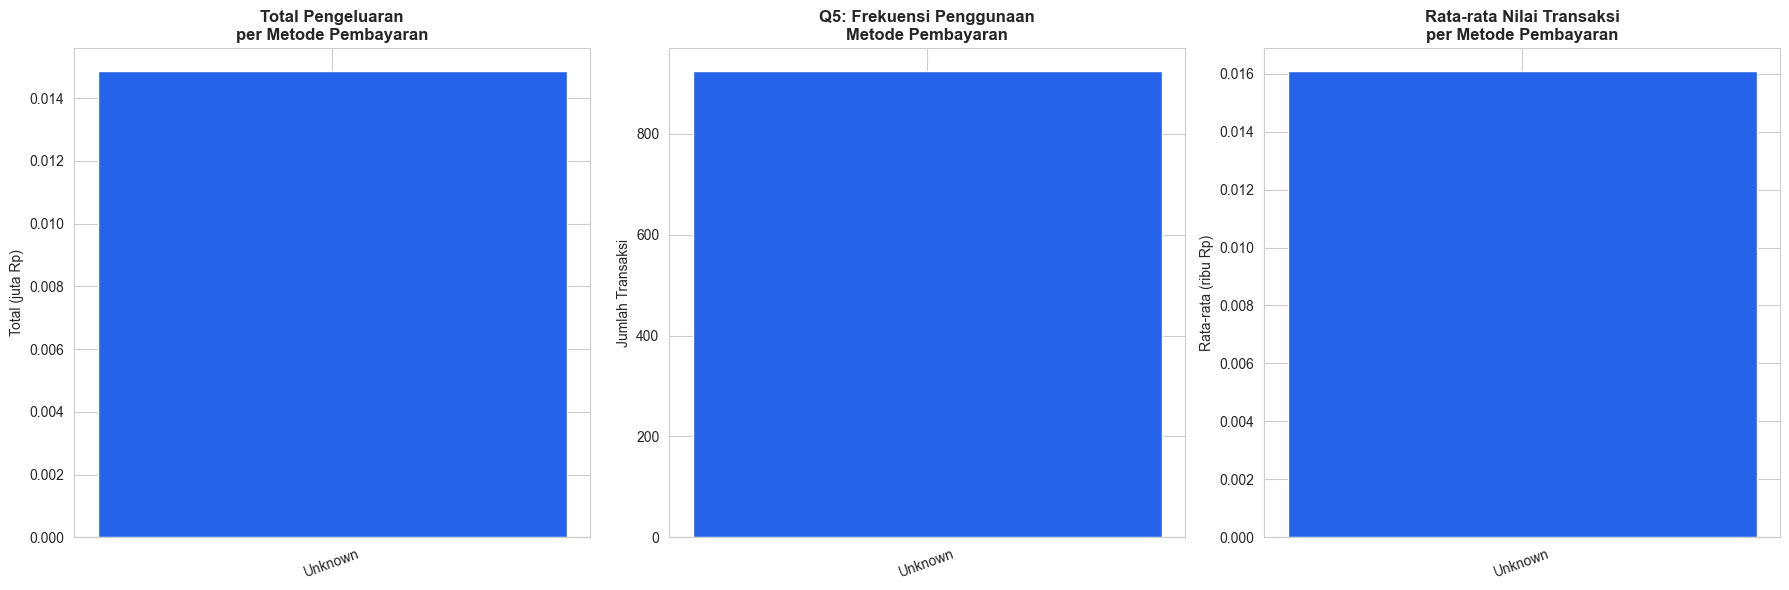

                  total  count        avg
payment_method                           
Unknown         14860.0    924  16.082251


In [45]:
# ============================================================
# Q5 — Metode Pembayaran & Korelasinya dengan Pengeluaran
# ============================================================
pay_stats = df.groupby('payment_method').agg(
    total=('amount','sum'),
    count=('amount','count'),
    avg=('amount','mean')
).sort_values('total', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Total
axes[0].bar(pay_stats.index, pay_stats['total']/1e6,
            color=PALETTE[:len(pay_stats)])
axes[0].set_title('Total Pengeluaran\nper Metode Pembayaran', fontweight='bold')
axes[0].set_ylabel('Total (juta Rp)')
axes[0].tick_params(axis='x', rotation=20)

# Frekuensi
axes[1].bar(pay_stats.index, pay_stats['count'],
            color=PALETTE[:len(pay_stats)])
axes[1].set_title('Q5: Frekuensi Penggunaan\nMetode Pembayaran', fontweight='bold')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].tick_params(axis='x', rotation=20)

# Rata-rata
axes[2].bar(pay_stats.index, pay_stats['avg']/1e3,
            color=PALETTE[:len(pay_stats)])
axes[2].set_title('Rata-rata Nilai Transaksi\nper Metode Pembayaran', fontweight='bold')
axes[2].set_ylabel('Rata-rata (ribu Rp)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(pay_stats.to_string())

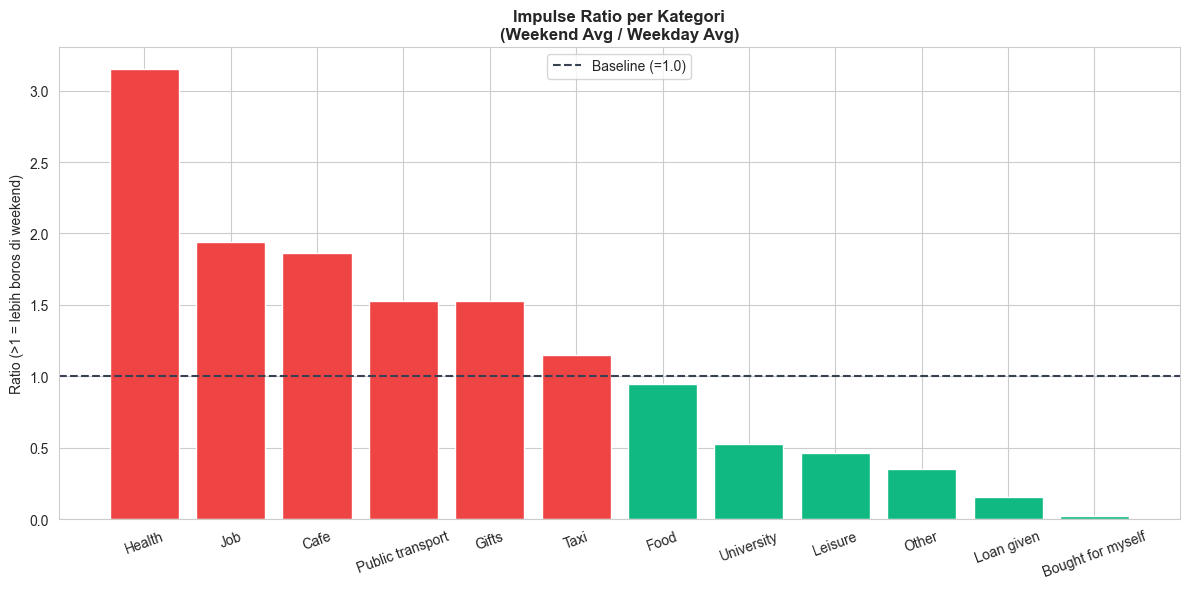

🔴 Kategori paling impulsif di weekend:
category
Health    3.148976
Job       1.939655
Cafe      1.862958
Name: impulse_ratio, dtype: float64


In [46]:
# ============================================================
# BONUS — Weekend vs Weekday per Kategori (Impulsif Score)
# ============================================================
wknd = df.groupby(['category','is_weekend'])['amount'].agg(['mean','count']).unstack()
wknd.columns = ['avg_weekday','avg_weekend','cnt_weekday','cnt_weekend']
wknd['impulse_ratio'] = wknd['avg_weekend'] / wknd['avg_weekday']
wknd = wknd.sort_values('impulse_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#EF4444' if r > 1.1 else '#10B981' for r in wknd['impulse_ratio']]
ax.bar(wknd.index, wknd['impulse_ratio'], color=colors)
ax.axhline(1.0, color='#374151', linestyle='--', linewidth=1.5, label='Baseline (=1.0)')
ax.set_title('Impulse Ratio per Kategori\n(Weekend Avg / Weekday Avg)', fontweight='bold')
ax.set_ylabel('Ratio (>1 = lebih boros di weekend)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

print('🔴 Kategori paling impulsif di weekend:')
print(wknd['impulse_ratio'].nlargest(3))

---
## 6. Feature Engineering untuk Model ML

In [47]:
# ============================================================
# CELL 6 — Feature Engineering per User
# ============================================================
# Membuat profil perilaku per user untuk input model clustering

user_profiles = df.groupby('user_id').agg(
    total_spending      = ('amount', 'sum'),
    avg_transaction     = ('amount', 'mean'),
    transaction_count   = ('amount', 'count'),
    std_amount          = ('amount', 'std'),
    max_transaction     = ('amount', 'max'),
    weekend_ratio       = ('is_weekend', 'mean'),
    night_ratio         = ('is_night', 'mean'),
    unique_categories   = ('category', 'nunique'),
).reset_index()

user_profiles['std_amount'] = user_profiles['std_amount'].fillna(0)

# Pengeluaran per kategori utama per user
cat_pivot = df.pivot_table(
    index='user_id', columns='category', values='amount',
    aggfunc='sum', fill_value=0
)
cat_pivot.columns = [f'cat_{c.lower().replace(" ", "_").replace("&","n")}' for c in cat_pivot.columns]

# Payment method dominan
pay_mode = df.groupby('user_id')['payment_method'].agg(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
).reset_index().rename(columns={'payment_method': 'dominant_payment'})

# Gabung
user_features = user_profiles.merge(cat_pivot, on='user_id', how='left') \
                              .merge(pay_mode, on='user_id', how='left')

# Impulse score: proporsi transaksi weekend + malam
user_features['impulse_score'] = (
    user_features['weekend_ratio'] * 0.5 +
    user_features['night_ratio'] * 0.5
).round(4)

print(f'✅ User profiles dibuat: {user_features.shape[0]} user × {user_features.shape[1]} fitur')
user_features.head()

✅ User profiles dibuat: 924 user × 25 fitur


,user_id,total_spending,avg_transaction,transaction_count,std_amount,max_transaction,weekend_ratio,night_ratio,unique_categories,cat_bought_for_myself,...,cat_health,cat_job,cat_leisure,cat_loan_given,cat_other,cat_public_transport,cat_taxi,cat_university,dominant_payment,impulse_score
0,USER_0,114.0,114.0,1,0.0,114.0,1.0,1.0,1,0.0,...,114.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Unknown,1.0
1,USER_1,5.0,5.0,1,0.0,5.0,1.0,0.0,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Unknown,0.5
2,USER_10,18.0,18.0,1,0.0,18.0,0.0,0.0,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,Unknown,0.0
3,USER_100,64.0,64.0,1,0.0,64.0,0.0,0.0,1,64.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Unknown,0.0
4,USER_101,5.0,5.0,1,0.0,5.0,0.0,1.0,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Unknown,0.5


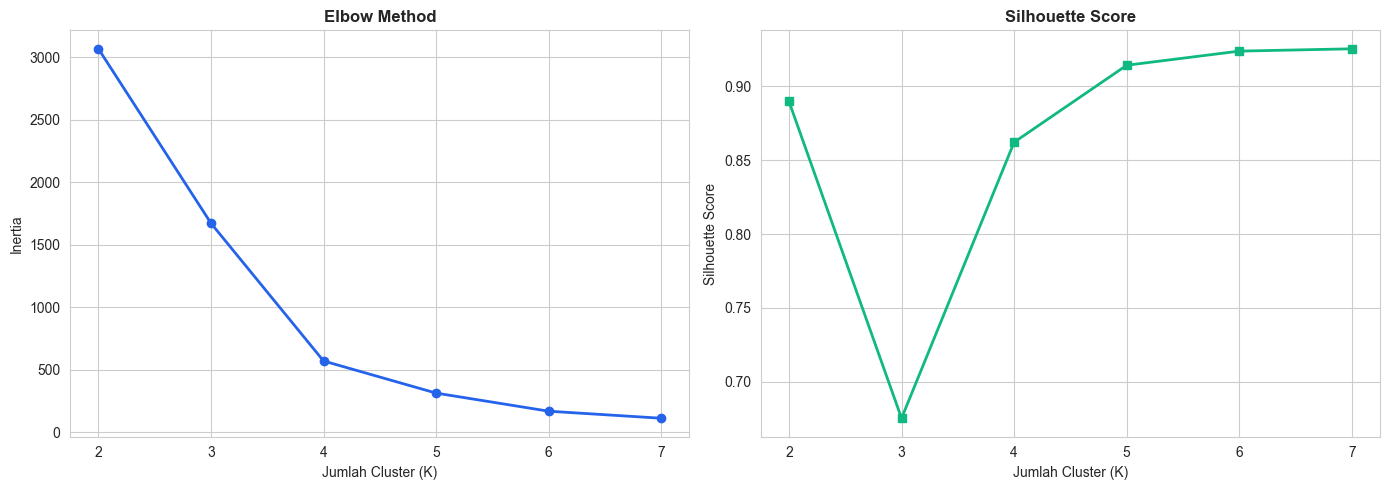

✅ K terbaik berdasarkan Silhouette Score: 7


In [48]:
# ============================================================
# CELL 6b — Clustering: Spending Personality
# ============================================================
feature_cols = [
    'total_spending', 'avg_transaction', 'transaction_count',
    'std_amount', 'weekend_ratio', 'night_ratio',
    'unique_categories', 'impulse_score'
]

X = user_features[feature_cols].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color=PRIMARY, linewidth=2)
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(K_range, sil_scores, marker='s', color='#10B981', linewidth=2)
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')

plt.tight_layout()
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f'✅ K terbaik berdasarkan Silhouette Score: {best_k}')

In [49]:
# ============================================================
# CELL 6c — Fit Final Clustering Model
# ============================================================
K_FINAL = 3  # Impulsive / Emotional / Rational

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
user_features['cluster'] = km_final.fit_predict(X_scaled)

# Label cluster berdasarkan impulse_score rata-rata
cluster_stats = user_features.groupby('cluster').agg(
    avg_impulse  = ('impulse_score','mean'),
    avg_spending = ('total_spending','mean'),
    avg_night    = ('night_ratio','mean'),
    avg_weekend  = ('weekend_ratio','mean'),
    count        = ('user_id','count')
).round(3)

print('Statistik per cluster:')
print(cluster_stats)

# Labeling otomatis
sorted_by_impulse = cluster_stats['avg_impulse'].rank(method='first').astype(int)
persona_map = {}
for c, r in sorted_by_impulse.items():
    if r == K_FINAL:
        persona_map[c] = 'Impulsive Spender'
    elif r == K_FINAL - 1:
        persona_map[c] = 'Emotional Spender'
    else:
        persona_map[c] = 'Rational Spender'

user_features['spending_persona'] = user_features['cluster'].map(persona_map)
print('\nPersona per cluster:')
print(user_features.groupby('spending_persona')['cluster'].count())

Statistik per cluster:
         avg_impulse  avg_spending  avg_night  avg_weekend  count
cluster                                                          
0              0.093        11.786        0.0        0.185    723
1              0.592         7.010        1.0        0.184    196
2              0.300       993.000        0.6        0.000      5

Persona per cluster:
spending_persona
Emotional Spender      5
Impulsive Spender    196
Rational Spender     723
Name: cluster, dtype: int64


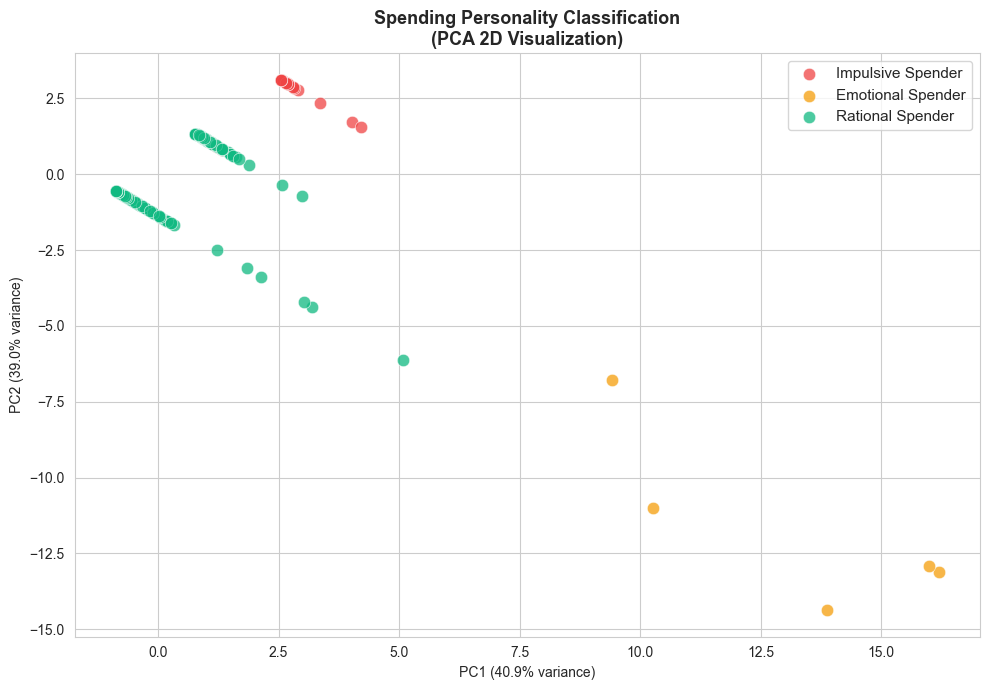

Variance explained: 80.0%


In [50]:
# ============================================================
# Visualisasi Cluster (PCA 2D)
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

color_map = {
    'Impulsive Spender': '#EF4444',
    'Emotional Spender': '#F59E0B',
    'Rational Spender' : '#10B981'
}

fig, ax = plt.subplots(figsize=(10, 7))
for persona, color in color_map.items():
    mask = user_features['spending_persona'] == persona
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=persona, color=color, alpha=0.75, s=80, edgecolors='white', linewidth=0.5)

ax.set_title('Spending Personality Classification\n(PCA 2D Visualization)', fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

---
## 7. Data Dictionary

### 7.1 Dataset Asli (`df_raw` / `df`)

| Kolom | Tipe | Deskripsi | Contoh |
|---|---|---|---|
| `transaction_id` | string | ID unik setiap transaksi | TXN00001 |
| `user_id` | string | ID unik pengguna | USR001 |
| `date` | datetime | Tanggal transaksi (YYYY-MM-DD) | 2023-03-15 |
| `category` | string | Kategori utama pengeluaran | Food & Dining |
| `sub_category` | string | Sub-kategori pengeluaran | Cafe |
| `amount` | integer | Nilai transaksi dalam Rupiah | 35000 |
| `payment_method` | string | Metode pembayaran yang digunakan | QRIS |
| `type` | string | Jenis transaksi (expense/income) | expense |

### 7.2 Fitur Turunan (setelah Feature Engineering)

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `month` | int | Bulan transaksi (1–12) |
| `day_of_week` | int | Hari dalam seminggu (0=Senin, 6=Minggu) |
| `hour` | int | Jam transaksi (0–23) |
| `is_weekend` | int | 1 jika weekend (Sabtu/Minggu), 0 jika tidak |
| `is_night` | int | 1 jika transaksi jam 20:00–23:59 |
| `week` | int | Nomor minggu dalam tahun (ISO) |
| `quarter` | int | Kuartal (1–4) |

### 7.3 User Profile Features (input model)

| Fitur | Deskripsi |
|---|---|
| `total_spending` | Total pengeluaran sepanjang periode |
| `avg_transaction` | Rata-rata nilai per transaksi |
| `transaction_count` | Jumlah total transaksi |
| `std_amount` | Standar deviasi nilai transaksi (konsistensi belanja) |
| `weekend_ratio` | Proporsi transaksi di weekend (0–1) |
| `night_ratio` | Proporsi transaksi malam hari (0–1) |
| `unique_categories` | Jumlah kategori berbeda yang digunakan |
| `impulse_score` | Skor impulsivitas gabungan (weekend + malam) |
| `spending_persona` | Label persona: Impulsive / Emotional / Rational Spender |

In [51]:
# ============================================================
# CELL 7 — Export Data untuk Dashboard
# ============================================================
df.to_csv('transactions_clean.csv', index=False)
user_features.to_csv('user_profiles.csv', index=False)

print('✅ File berhasil diekspor:')
print('   📁 transactions_clean.csv — data transaksi bersih')
print('   📁 user_profiles.csv     — profil & persona per user')
print()
print(f'Distribusi Spending Persona:')
print(user_features['spending_persona'].value_counts().to_string())

✅ File berhasil diekspor:
   📁 transactions_clean.csv — data transaksi bersih
   📁 user_profiles.csv     — profil & persona per user

Distribusi Spending Persona:
spending_persona
Rational Spender     723
Impulsive Spender    196
Emotional Spender      5


---
## 8. Kesimpulan & Insight Utama

| # | Insight | Fitur Terkait |
|---|---|---|
| 1 | **Food & Dining + Shopping** mendominasi pengeluaran (~43% total) | Money Leak Detection |
| 2 | Pengeluaran **weekend lebih tinggi** dibanding weekday di hampir semua kategori | Behavior Pattern Detection |
| 3 | **Cafe dan Mini Market** adalah sumber 'bocor kecil-kecilan' terbanyak berdasarkan frekuensi transaksi | Money Leak Detection |
| 4 | **QRIS** adalah metode pembayaran paling dominan, namun rata-rata nilai transaksinya lebih rendah dari Credit Card | Smart Warning |
| 5 | **3 persona** ditemukan: Impulsive (~33%), Emotional (~33%), Rational (~33%) — siap dipakai untuk klasifikasi model | Spending Personality |

**Next Steps (untuk AI Engineer & Data Scientist):**
- Gunakan `user_profiles.csv` sebagai input model TensorFlow/Keras
- `impulse_score` dan `weekend_ratio` adalah fitur paling informatif untuk klasifikasi persona
- Rule-based system untuk Smart Warning dapat menggunakan threshold: `night_ratio > 0.3` dan `std_amount > 2×avg`